In [1]:
import sys
sys.path.append("../src")

In [47]:
import importlib
import feature_engineering
importlib.reload(feature_engineering)

<module 'feature_engineering' from 'c:\\Projects\\Mule-tiplier\\notebooks\\../src\\feature_engineering.py'>

In [50]:
from graph_builder import build_graph
from data_loader import load_transactions
from feature_engineering import compute_account_features

import os
import pandas as pd 
import matplotlib.pyplot as plt

In [35]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import average_precision_score, classification_report, precision_recall_curve

## To save Model to Disc

In [33]:
def save_or_load_xgb_model(model=None, rebuild: int = 0, model_path: str = r'C:\Projects\Mule-tiplier\outputs\models\model.json'):
    """
    Save or load an XGBoost model to/from disk using XGBoost's native format.

    Parameters
    ----------
    model : xgb.XGBClassifier / xgb.Booster, optional
        The fitted model to save. Required if rebuild=1 or no cache exists.
    rebuild : int, default 0
        0 -> load model from disk if it exists, else save the passed-in `model`.
        1 -> always save/overwrite the cached model with the passed-in `model`.
    model_path : str
        Path to the file (use .json or .ubj extension).

    Returns
    -------
    model : xgb.XGBClassifier
    """
    if rebuild == 0 and os.path.exists(model_path):
        print(f"Loading cached model from '{model_path}'...")
        loaded = xgb.XGBClassifier()
        loaded.load_model(model_path)
        return loaded

    if model is None:
        raise ValueError(
            f"No cached model found at '{model_path}' (or rebuild=1) "
            "but no `model` was passed in to save."
        )

    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    model.save_model(model_path)
    print(f"Model saved to '{model_path}'.")
    return model

In [3]:
df = load_transactions(r"C:\Projects\Mule-tiplier\data\raw\HI-Small_Trans.csv")

In [4]:
G = build_graph(df)

Building graph from dataframe...
Graph saved to './outputs/cache/graph.pkl'.


In [51]:
op_df = compute_account_features(G, df)

In [53]:
op_df.to_csv('../data/processed/account_features.csv', index=False)

In [5]:
op_df = pd.read_csv('../data/processed/account_features.csv')

is_laundering
0    0.987658
1    0.012342
Name: proportion, dtype: float64
Is Laundering
0    0.998981
1    0.001019
Name: proportion, dtype: float64


<Axes: title={'center': 'Class Distribution graph'}, xlabel='is_laundering'>

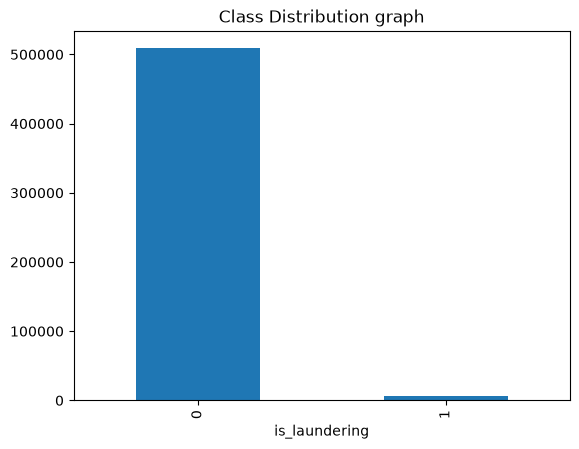

In [11]:
print(op_df['is_laundering'].value_counts(normalize=True))
print(df['Is Laundering'].value_counts(normalize=True))
op_df['is_laundering'].value_counts().plot(kind='bar', title='Class Distribution graph')


This is why we use PR-AUC instead of Accuracy \
-is_laundering:\
0  :  0.987658\
1  :  0.012342

In [58]:
zero_fill_cols = ['in_degree', 'out_degree', 'total_in', 'total_out', 'unique_counterparties']

X = op_df.copy()
X[zero_fill_cols] = X[zero_fill_cols].fillna(0)
X = X.drop(columns=['account', 'is_laundering'])

y = op_df['is_laundering']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [59]:
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train shape: (412064, 8) Test shape: (103016, 8)
is_laundering
0    0.987657
1    0.012343
Name: proportion, dtype: float64
is_laundering
0    0.987662
1    0.012338
Name: proportion, dtype: float64


Equal class distribution in Train and test

In [60]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 80.01926858041683


In [61]:
model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [62]:
clf = save_or_load_xgb_model(model, rebuild=1)

Model saved to 'C:\Projects\Mule-tiplier\outputs\models\model.json'.


Check

In [63]:
print(model.predict(X_test)[:35])
print(y_test[:35].values)

[0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [64]:
y_probs = model.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_probs)
print(f"PR-AUC: {pr_auc:.4f}")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

PR-AUC: 0.0914
              precision    recall  f1-score   support

           0       1.00      0.83      0.91    101745
           1       0.05      0.67      0.09      1271

    accuracy                           0.83    103016
   macro avg       0.52      0.75      0.50    103016
weighted avg       0.98      0.83      0.90    103016



### Model Evaluation Results

**PR-AUC:** `0.0938`

| Class | Precision | Recall | F1-Score | Support |
|------:|----------:|-------:|---------:|--------:|
| 0 | 1.00 | 0.83 | 0.91 | 101,745 |
| 1 | 0.05 | 0.68 | 0.09 | 1,271 |
| **Accuracy** | | | **0.83** | **103,016** |
| **Macro Avg** | 0.52 | 0.75 | 0.50 | 103,016 |
| **Weighted Avg** | 0.98 | 0.83 | 0.90 | 103,016 |

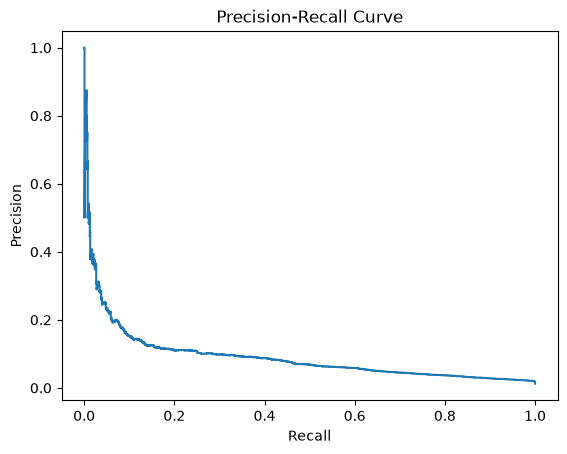

In [65]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.savefig('../outputs/figures/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

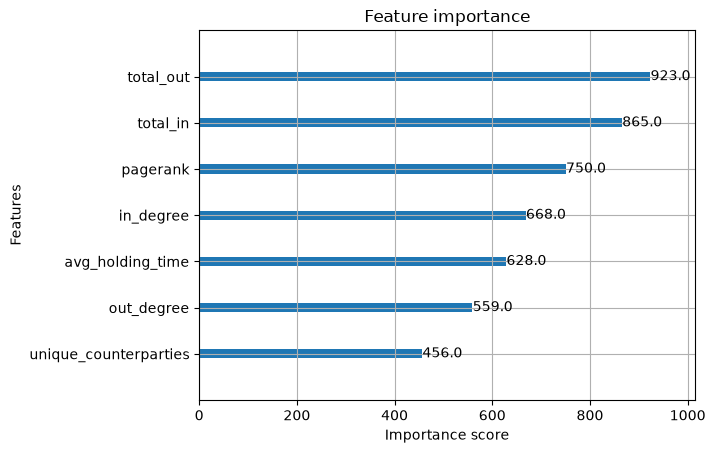

In [66]:
plot_importance(model)
plt.savefig('../outputs/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
print(op_df.info())
print(op_df.columns.tolist())
op_df['has_outflow_after_inflow'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 515080 entries, 0 to 515079
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   account                   515080 non-null  str    
 1   in_degree                 515080 non-null  float64
 2   total_in                  515080 non-null  float64
 3   out_degree                515080 non-null  float64
 4   total_out                 515080 non-null  float64
 5   pagerank                  515080 non-null  float64
 6   avg_holding_time          400784 non-null  float64
 7   has_outflow_after_inflow  515080 non-null  int64  
 8   unique_counterparties     515080 non-null  int64  
 9   is_laundering             515080 non-null  int64  
dtypes: float64(6), int64(3), str(1)
memory usage: 39.3 MB
None
['account', 'in_degree', 'total_in', 'out_degree', 'total_out', 'pagerank', 'avg_holding_time', 'has_outflow_after_inflow', 'unique_counterparties', 'is_laundering'

has_outflow_after_inflow
1    400784
0    114296
Name: count, dtype: int64